# TP1

**Author: Danilo Reitano**

The following notebook is an example of a really tiny GPT based model called TinyGPT.
You'll review the GPT architecture (transformer decoder) and implement the following tasks:

## TinyGPT Architecture

Tailored for the [NLP-II course](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/CEIA-LLMIAG) as we deal with architectures and theory, this model consists of a **Mixture of Experts GPT**, equivalent to models like:
- DeepSeek
- Mistral

## Tasks

Using TinyGPT you need to implement the following modifications:


## Inference: Modify the generate function to:
- Greedy decoding (pick max probability token).
- Temperature sampling.
- top-k or top-p sampling.

### References
- [huggingface generate](https://huggingface.co/docs/transformers/main_classes/text_generation)

## Architecture:
- Make TinyGPT a Mixture of Experts (MoE) of at least 2 experts.

## What to expect?

- You'll manage to understand a depth implementation of a GPT model.
- Implement a MoE Layer to create a state-of-the art GPT model.
- Explore decoding algorithms for text generation.


### NOTE

Tokenization is out of scope, we'll use a simple yet ineffective character-based tokenizer.


In [15]:
import torch
from torch import nn
import torch.nn.functional as F
from dataclasses import dataclass, field
from typing import Optional, List, Type
import httpx

from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

from trainer import Trainer
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR

## Downloading Dataset

In [44]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = httpx.get(url)
text = response.text

text = text[:100_000]  # Using 100k characters for speedup
print(text[:200])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


# Character-based encoding

In [17]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}
def encode(s): return [stoi[c] for c in s]
def decode(l): return ''.join([itos[i] for i in l])
data = torch.tensor(encode(text), dtype=torch.long)

# Train/test split
split = int(0.9 * len(data))
train_data = data[:split]
val_data = data[split:]

# Dataloaders

In [18]:
class CharDataset(Dataset):
    def __init__(self, data: torch.Tensor, block_size: int):
        self.data = data
        self.block_size = block_size

    def __len__(self):
        return len(self.data) - self.block_size

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.block_size]
        y = self.data[idx + 1 : idx + self.block_size + 1]
        return x, y

# GPT Configuration

In [19]:
@dataclass
class MoEArgs():
    """
    MoE input arguments class.
    """
    num_experts : int = field(default=4)
    num_experts_per_token : int = field(default=2)

@dataclass
class GPTConfig:
    """
    Base class for GPT models.
    """
    block_size: int = 32
    batch_size: int = 2048
    n_embd: int = 64
    n_head: int = 4
    n_layer: int = 2
    dropout: float = 0.1
    vocab_size: int = vocab_size
    bias: bool = True
    ff_class: Optional[Type[nn.Module]] = None
    moe : Optional[MoEArgs] = None

config = GPTConfig()
print(config.__dict__)

{'block_size': 32, 'batch_size': 2048, 'n_embd': 64, 'n_head': 4, 'n_layer': 2, 'dropout': 0.1, 'vocab_size': 61, 'bias': True, 'ff_class': None, 'moe': None}


In [20]:
train_dataset = CharDataset(train_data, config.block_size)
val_dataset = CharDataset(val_data, config.block_size)

train_loader = DataLoader(train_dataset,
                        batch_size=config.batch_size,
                        shuffle=True,
                        drop_last=True,
                        pin_memory=True,
                        num_workers= 0, # if using mps set num_workers as 0.
                        )
val_loader = DataLoader(val_dataset,
                        batch_size=config.batch_size,
                        shuffle=False,
                        drop_last=True,
                        pin_memory=True,
                        num_workers= 0,
                        )

In [21]:
class AttentionHead(nn.Module):
    """
    Scaled Dot-Product Attention Head for Multi-Head Attention.
    """
    def __init__(self, args: GPTConfig) -> None:
        super().__init__()
        assert args.n_embd % args.n_head == 0, "n_embd must be divisible by n_head"
        self.head_dim = args.n_embd // args.n_head

        # Combined QKV projection
        self.key_query_value = nn.Linear(args.n_embd, 3 * self.head_dim, bias=args.bias)

        self.dropout = nn.Dropout(args.dropout)
        self.block_size = args.block_size
        self.register_buffer('tril', torch.tril(torch.ones(args.block_size, args.block_size)))

    def forward(self, x: torch.Tensor, kv_cache: Optional[torch.Tensor] = None, return_weights=False):
        B, T, C = x.shape
        key_query_value = self.key_query_value(x)  # (B, T, 3 * head_dim)
        k, q, v = torch.chunk(key_query_value, 3, dim=-1)  # (B, T, head_dim) each

        if kv_cache is not None:
            key_cache, value_cache = kv_cache.unbind(dim=0)  # (B, T', head_dim)
            k = torch.cat((key_cache, k), dim=1)
            v = torch.cat((value_cache, v), dim=1)

        # Scaled dot-product attention
        wei = q @ k.transpose(-2, -1) * (self.head_dim ** -0.5)  # (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)

        out = wei @ v  # (B, T, head_dim)

        if return_weights:
            return out, wei

        if kv_cache is not None:
            return out, torch.stack((k, v))

        return out, None

In [22]:
class MultiHeadAttention(nn.Module):
    def __init__(self, args: GPTConfig):
        super().__init__()
        assert args.n_embd % args.n_head == 0, "n_embd must be divisible by n_head"
        self.n_heads = args.n_head
        self.head_dim = args.n_embd // args.n_head

        self.heads = nn.ModuleList([
            AttentionHead(args) for _ in range(self.n_heads)
        ])

        self.proj = nn.Linear(args.n_embd, args.n_embd, bias=args.bias)
        self.dropout = nn.Dropout(args.dropout)

    def forward(self, x, kv_cache=None, return_weights=False):
        all_outputs = []
        all_weights = []
        new_kv_cache = [] if kv_cache is not None else None

        for i, head in enumerate(self.heads):
            head_cache = kv_cache[i] if kv_cache is not None else None
            out, weights_or_kv = head(x, kv_cache=head_cache, return_weights=return_weights)
            all_outputs.append(out)
            if return_weights:
                all_weights.append(weights_or_kv)
            if kv_cache is not None:
                new_kv_cache.append(weights_or_kv)  # weights_or_kv is new kv_cache here

        concat = torch.cat(all_outputs, dim=-1)  # concat along embedding dim
        out = self.dropout(self.proj(concat))

        if return_weights:
            return out, torch.stack(all_weights)
        if kv_cache is not None:
            return out, new_kv_cache
        return out

In [23]:
class FeedForward(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.ReLU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.ln2 = nn.LayerNorm(config.n_embd)
        self.attn = MultiHeadAttention(config)

        ff_class = config.ff_class if config.ff_class is not None else FeedForward
        self.ff = ff_class(config)

    def forward(self, x, kv_cache=None, return_weights=False):
        attn_out = self.attn(self.ln1(x), kv_cache=kv_cache, return_weights=return_weights)
        if return_weights:
            attn_out, weights = attn_out
        else:
            weights = None

        if isinstance(attn_out, tuple):
            attn_out, updated_kv = attn_out
        else:
            updated_kv = None

        x = x + attn_out
        x = x + self.ff(self.ln2(x))
        return (x, updated_kv, weights) if return_weights else (x, updated_kv)

## TinyGPT Architecture

In [24]:
class TinyGPT(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.token_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)
        self.blocks = nn.ModuleList([Block(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.n_embd)
        self.head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.config = config

    def forward(self, idx, kv_cache=None, return_weights=False):
        B, T = idx.shape
        tok_emb = self.token_emb(idx)
        pos = torch.arange(T, device=idx.device)
        pos_emb = self.pos_emb(pos)[None, :, :]
        x = tok_emb + pos_emb

        new_kv_cache = [] if kv_cache is not None else None
        all_weights = [] if return_weights else None

        for i, block in enumerate(self.blocks):
            layer_kv = kv_cache[i] if kv_cache is not None else None
            if return_weights:
                x, updated_kv, weights = block(x, kv_cache=layer_kv, return_weights=True)
                all_weights.append(weights)  # weights shape: (n_heads, B, T, T)
            else:
                x, updated_kv = block(x, kv_cache=layer_kv)
            if kv_cache is not None:
                new_kv_cache.append(updated_kv)

        x = self.ln_f(x)
        logits = self.head(x)

        if return_weights:
            if kv_cache is not None:
                return logits, new_kv_cache, all_weights
            else:
                return logits, all_weights
        else:
            if kv_cache is not None:
                return logits, new_kv_cache
            return logits


## Generation function (inference)

In [25]:
@torch.no_grad()
def generate(prompt: str, max_new_tokens: int = 100, use_cache: bool = True, model: nn.Module = None):
    model.eval()
    idx = torch.tensor(encode(prompt), dtype=torch.long)[None, :].to(device)
    kv_cache = None

    for _ in range(max_new_tokens):
        if use_cache and kv_cache is not None:
            idx_cond = idx[:, -1:]
        else:
            idx_cond = idx[:, -config.block_size:]

        out = model(idx_cond, kv_cache=kv_cache) if use_cache else model(idx_cond)

        if isinstance(out, tuple):
            logits, kv_cache = out
        else:
            logits = out
            kv_cache = None

        probs = F.softmax(logits[:, -1, :], dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, next_token), dim=1)

    return decode(idx[0].tolist())

# Setup

In [26]:
device =  'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
m = TinyGPT(config).to(device)
model = torch.compile(m)

In [27]:
optimizer = AdamW(model.parameters(), lr=1e-3)
scheduler = StepLR(optimizer, step_size=100, gamma=0.9)
loss_fn = torch.nn.CrossEntropyLoss()
epochs = 10

# Training

In [28]:
# Trainer instance
trainer = Trainer(
    model=model,
    train_data_loader=train_loader,
    test_data_loader=val_loader,
    loss_fn=loss_fn,
    gradient_accumulation_steps=1,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    save_dir="./checkpoints",
    save_every_n=500
)
# Training
for epoch in range(epochs):  
    avg_train_loss = trainer.train_model_v2(use_amp=True, dtype=torch.bfloat16)
    print(f"Epoch {epoch+1} training loss: {avg_train_loss:.4f}")

    val_loss = trainer.eval_model()
    print(f"Epoch {epoch+1} validation loss: {val_loss:.4f}")

print("Training complete.")

loss 3.10501: 100%|██████████| 43/43 [00:45<00:00,  1.06s/it]


Epoch 1 training loss: 3.0345


  0%|          | 0/4 [00:00<?, ?it/s]/Users/dreitano/projects/maestria/CEIA-LLMIAG/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
val_loss 2.91570: 100%|██████████| 4/4 [00:02<00:00,  1.36it/s]


Epoch 1 validation loss: 2.9199


  0%|          | 0/43 [00:00<?, ?it/s]/Users/dreitano/projects/maestria/CEIA-LLMIAG/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
loss 2.79839: 100%|██████████| 43/43 [00:38<00:00,  1.13it/s]


...

Epoch 9 validation loss: 1.9436


loss 2.53794: 100%|██████████| 43/43 [00:33<00:00,  1.28it/s]


Epoch 10 training loss: 2.3129


val_loss 2.02479: 100%|██████████| 4/4 [00:00<00:00, 15.69it/s]

Epoch 10 validation loss: 1.9423
Training complete.


### Quick test 

In [29]:
generate("To be", max_new_tokens=100, use_cache=True, model=model) 

"To bey, wh maghour brevon,\nThan the'e benooth, wamy s! monour anothe!\nWhard gares arand  the more pof an "

# Task I

Using TinyGPT you need to implement the following modifications:


## Inference: Modify the generate function to:
- Greedy decoding (pick max probability token).
- Temperature sampling.
- top-k or top-p sampling.

### References
- [huggingface generate](https://huggingface.co/docs/transformers/main_classes/text_generation)



In [30]:
@torch.no_grad()
def generateV2(
    prompt: str,
    max_new_tokens: int = 100,
    use_cache: bool = True,
    model: nn.Module = None,
    temperature: float = 1.0,
    top_k: int = 0,  # 0 means disabled
    top_p: float = 1.0,  # 1.0 means disabled
)-> Optional[str]:
    """
    Enhanced generation function with multiple sampling strategies.
    
    Args:
        prompt: Input text prompt
        max_new_tokens: Maximum number of tokens to generate
        use_cache: Whether to use KV cache for faster generation
        temperature: Sampling temperature (0.0 = greedy, >0.0 = sampling)
        top_k: Keep only top k tokens (0 = disabled)
        top_p: Nucleus sampling - keep tokens with cumulative prob <= top_p (1.0 = disabled)
    
    Returns:
        Generated text string
    """
    model.eval()
    idx = torch.tensor(encode(prompt), dtype=torch.long)[None, :].to(device)
    kv_cache = None

    for _ in range(max_new_tokens):
        if use_cache and kv_cache is not None:
            idx_cond = idx[:, -1:]
        else:
            idx_cond = idx[:, -config.block_size:]

        out = model(idx_cond, kv_cache=kv_cache) if use_cache else model(idx_cond)

        if isinstance(out, tuple):
            logits, kv_cache = out
        else:
            logits = out
            kv_cache = None

        # Get logits for the last token
        logits = logits[:, -1, :]  # (batch_size, vocab_size)
        
        # Apply temperature
        if temperature == 0.0:
            # Greedy decoding: pick the token with highest probability
            next_token = torch.argmax(logits, dim=-1, keepdim=True)
        else:
            # Temperature sampling: scale logits by temperature
            logits = logits / temperature
            
            # Apply top-k filtering if specified
            if top_k > 0:
                # Get top-k values and indices
                top_k_values, top_k_indices = torch.topk(logits, min(top_k, logits.size(-1)), dim=-1)
                # Create a mask: set all other logits to -inf
                logits_filtered = torch.full_like(logits, float('-inf'))
                logits_filtered.scatter_(-1, top_k_indices, top_k_values)
                logits = logits_filtered
            
            # Apply top-p (nucleus) sampling if specified
            if top_p < 1.0:
                # Sort probabilities in descending order
                sorted_logits, sorted_indices = torch.sort(logits, descending=True, dim=-1)
                sorted_probs = F.softmax(sorted_logits, dim=-1)
                
                # Calculate cumulative probabilities
                cumsum_probs = torch.cumsum(sorted_probs, dim=-1)
                
                # Create mask: remove tokens with cumulative probability > top_p
                # Keep at least one token (the most probable one)
                sorted_indices_to_remove = cumsum_probs > top_p
                sorted_indices_to_remove[..., 0] = False  # Keep at least one token
                
                # Apply mask to sorted logits
                sorted_logits[sorted_indices_to_remove] = float('-inf')
                
                # Unsort back to original order
                _, unsorted_indices = torch.sort(sorted_indices, dim=-1)
                logits = torch.gather(sorted_logits, -1, unsorted_indices)
            
            # Convert to probabilities and sample
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
        
        idx = torch.cat((idx, next_token), dim=1)

    return decode(idx[0].tolist())

## Compare generate vs generateV2

Add your comments and findings

In [31]:
test_prompts = [
    "To be or not to be",
    "The king said",
    "Once upon a time",
    "Hello world"
]


for prompt in test_prompts: 
    print(f"\n{'='*60}")
    print(f"Testing prompt: '{prompt}'")
    print('='*60)
    
    # Greedy (deterministic)
    print("\n[Greedy]")
    print(generateV2(prompt, max_new_tokens=30, model=model, temperature=0.0))
    
    # Creative (high temp)
    print("\n[Creative - High Temp]")
    print(generateV2(prompt, max_new_tokens=30, model=model, temperature=1.5))
    
    # Balanced (medium temp + top-k)
    print("\n[Balanced - Temp + Top-k]")
    print(generateV2(prompt, max_new_tokens=30, model=model, temperature=0.8, top_k=10))
    
    # Focused (low temp + top-p)
    print("\n[Focused - Low Temp + Top-p]")
    print(generateV2(prompt, max_new_tokens=30, model=model, temperature=0.5, top_p=0.9))



Testing prompt: 'To be or not to be'

[Greedy]
To be or not to be the the the peare the peare t

[Creative - High Temp]
To be or not to be
n.
'w TheNo,, we -Cay'on thes

[Balanced - Temp + Top-k]
To be or not to beave hat we my heave atle.

As 

[Focused - Low Temp + Top-p]
To be or not to beat the the mad wour and not th

Testing prompt: 'The king said'

[Greedy]
The king said the sould the pon the the pea

[Creative - High Temp]
The king saide? willm.ve knee calltuumeall:

[Balanced - Temp + Top-k]
The king saids.

CORIOLRIOLANUS:
He to me p

[Focused - Low Temp + Top-p]
The king said some for the suld the mand fi

Testing prompt: 'Once upon a time'

[Greedy]
Once upon a time the sour the pood the peare t

[Creative - High Temp]
Once upon a time sindy, zof ie s. Warzevef Wis

[Balanced - Temp + Top-k]
Once upon a time so mor, in in my pettell the 

[Focused - Low Temp + Top-p]
Once upon a time the and stere cone speopen,
T

Testing prompt: 'Hello world'

[Greedy]
Hello world the por

## Task II
- Make TinyGPT a Mixture of Experts (MoE) of at least 2 experts.

In [32]:
class Expert(nn.Module):
    """
    An expert MLP instance from within a MoE.
    """

    def __init__(self,config:GPTConfig) -> None:
        """
        Initiates expert MLP given dimensions/hidden dimensions.
        """
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.ReLU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout)
        ) ## Example network

    def forward(self, x) -> torch.Tensor:
        """
        Forward pass through the expert network.
        
        Args:
            x: Input tensor of shape (batch_size, seq_len, n_embd)
        
        Returns:
            Output tensor of shape (batch_size, seq_len, n_embd)
        """
        return self.net(x)


class Gate(nn.Module):
    """
    MoE gating network MLP.
    """

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.proj = nn.Linear(config.n_embd, config.moe.num_experts)

    def forward(self, x):
        return self.proj(x)

In [33]:
class MoELayer(nn.Module):
    """
    Mixture of experts FeedForward Layer
    """

    def __init__(self, experts : List[nn.Module], gate : nn.Module, moe_args : MoEArgs):
        super().__init__()
        self.experts = nn.ModuleList(experts)
        self.gate = gate
        self.args = moe_args

    def forward(self, x : torch.Tensor) -> torch.Tensor:
        """
        Forward pass through MoE layer.
        
        Args:
            x: Input tensor of shape (batch_size, seq_len, n_embd)
        
        Returns:
            Output tensor of shape (batch_size, seq_len, n_embd)
        """
        batch_size, seq_len, n_embd = x.shape
        
        # Compute gate logits: (batch_size, seq_len, num_experts)
        gate_logits = self.gate(x)
        
        # Select top-k experts per token
        # top_k_values: (batch_size, seq_len, num_experts_per_token)
        # top_k_indices: (batch_size, seq_len, num_experts_per_token)
        top_k_values, top_k_indices = torch.topk(
            gate_logits, 
            k=self.args.num_experts_per_token, 
            dim=-1
        )
        
        # Apply softmax to get routing weights (only over selected experts)
        routing_weights = F.softmax(top_k_values, dim=-1)  # (batch_size, seq_len, num_experts_per_token)
        
        # Initialize output tensor
        output = torch.zeros_like(x)  # (batch_size, seq_len, n_embd)
        
        # Process each expert
        for expert_idx, expert in enumerate(self.experts):
            # Find positions where this expert is selected
            # Create mask: (batch_size, seq_len, num_experts_per_token)
            expert_mask = (top_k_indices == expert_idx)
            
            # Get the weight for this expert at each position
            # If expert is selected, use its routing weight; otherwise 0
            expert_weights = (expert_mask.float() * routing_weights).sum(dim=-1)  # (batch_size, seq_len)
            
            # Only compute expert output where it's selected (for efficiency)
            if expert_weights.sum() > 0:
                # Compute expert output for all positions
                expert_output = expert(x)  # (batch_size, seq_len, n_embd)
                
                # Weight the expert output by routing weights
                # Expand expert_weights to match output dimensions
                expert_weights_expanded = expert_weights.unsqueeze(-1)  # (batch_size, seq_len, 1)
                weighted_output = expert_output * expert_weights_expanded
                
                # Accumulate to output
                output = output + weighted_output
        
        return output

In [34]:
class MoEFFN(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.moe = MoELayer(  
            experts=[Expert(config) for _ in range(config.moe.num_experts)],
            gate=Gate(config),
            moe_args=config.moe
        )

    def forward(self, x):
        return self.moe(x)

## Adding MoE to Config

In [35]:
config.ff_class = MoEFFN
config.moe = MoEArgs(num_experts=4, num_experts_per_token=2)

# Training TinyGPT-MoE


In [36]:
m_moe = TinyGPT(config).to(device)
model_moe = torch.compile(m_moe)

In [37]:
optimizer = AdamW(model_moe.parameters(), lr=1e-3)
scheduler = StepLR(optimizer, step_size=100, gamma=0.9)
loss_fn = torch.nn.CrossEntropyLoss()
epochs = 10

In [38]:
# Trainer instance
trainer = Trainer(
    model=model_moe,
    train_data_loader=train_loader,
    test_data_loader=val_loader,
    loss_fn=loss_fn,
    gradient_accumulation_steps=1,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    save_dir="./checkpoints",
    save_every_n=500
)
# Training
for epoch in range(epochs): 
    avg_train_loss = trainer.train_model_v2(use_amp=True, dtype=torch.bfloat16)
    print(f"Epoch {epoch+1} training loss: {avg_train_loss:.4f}")

    val_loss = trainer.eval_model()
    print(f"Epoch {epoch+1} validation loss: {val_loss:.4f}")

print("Training complete.")

  0%|          | 0/43 [00:00<?, ?it/s]/Users/dreitano/projects/maestria/CEIA-LLMIAG/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
loss 2.79520: 100%|██████████| 43/43 [00:36<00:00,  1.19it/s]


Epoch 1 training loss: 2.7389


  0%|          | 0/4 [00:00<?, ?it/s]/Users/dreitano/projects/maestria/CEIA-LLMIAG/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
val_loss 2.66549: 100%|██████████| 4/4 [00:03<00:00,  1.09it/s]


Epoch 1 validation loss: 2.6464


  0%|          | 0/43 [00:00<?, ?it/s]/Users/dreitano/projects/maestria/CEIA-LLMIAG/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
loss 2.37797: 100%|██████████| 43/43 [00:30<00:00,  1.39it/s]


...

Epoch 9 validation loss: 1.6898


loss 1.69494: 100%|██████████| 43/43 [00:30<00:00,  1.43it/s]


Epoch 10 training loss: 1.6913


val_loss 1.77689: 100%|██████████| 4/4 [00:02<00:00,  1.68it/s]

Epoch 10 validation loss: 1.6701
Training complete.


In [39]:
test_prompts = [
    "To be or not to be",
    "The king said",
    "Once upon a time",
    "Hello world"
]


for prompt in test_prompts: 
    print(f"\n{'='*60}")
    print(f"Testing prompt: '{prompt}'")
    print('='*60)
    
    # Greedy (deterministic)
    print("\n[Greedy]")
    print(generateV2(prompt, max_new_tokens=30, model=model_moe, temperature=0.0))
    
    # Creative (high temp)
    print("\n[Creative - High Temp]")
    print(generateV2(prompt, max_new_tokens=30, model=model_moe, temperature=1.5))
    
    # Balanced (medium temp + top-k)
    print("\n[Balanced - Temp + Top-k]")
    print(generateV2(prompt, max_new_tokens=30, model=model_moe, temperature=0.8, top_k=10))
    
    # Focused (low temp + top-p)
    print("\n[Focused - Low Temp + Top-p]")
    print(generateV2(prompt, max_new_tokens=30, model=model_moe, temperature=0.5, top_p=0.9))


Testing prompt: 'To be or not to be'

[Greedy]
To be or not to be the people to the people the 

[Creative - High Temp]
To be or not to bet
'Tinven, xfly, Coriolace; fl

[Balanced - Temp + Top-k]
To be or not to begircy.

SICINIUS:
Sell suck sh

[Focused - Low Temp + Top-p]
To be or not to be stake the make the prity, the

Testing prompt: 'The king said'

[Greedy]
The king said the people the consul, the pe

[Creative - High Temp]
The king said Corioli:
Nerthisdon gmenduben

[Balanced - Temp + Top-k]
The king said should and me to mist for sul

[Focused - Low Temp + Top-p]
The king said the be many of the people be 

Testing prompt: 'Once upon a time'

[Greedy]
Once upon a time the prouse the people to the 

[Creative - High Temp]
Once upon a timer-and: Nor havy to suDe,
Butom

[Balanced - Temp + Top-k]
Once upon a time of the preepeaple furess mose

[Focused - Low Temp + Top-p]
Once upon a time the sto dest in the marke the

Testing prompt: 'Hello world'

[Greedy]
Hello world the peo

## Visualizing Attention

As we know, a GPT has the task to complete text, let's see the attention maps generated by a pretrained model

In [40]:
@torch.no_grad()
def visualize_attention(model, prompt, max_len=10):
    model.eval()
    idx = torch.tensor(encode(prompt), dtype=torch.long)[None, :].to(device)

    # Run forward with return_weights=True
    logits, all_weights = model(idx, return_weights=True)

    # all_weights is a list of length n_layers
    # each element: shape (n_heads, batch_size, seq_len, seq_len)
    # We'll visualize the first batch element only

    n_layers = len(all_weights)
    n_heads = all_weights[0].shape[0]
    seq_len = all_weights[0].shape[-1]

    for layer_i in range(n_layers):
        fig, axes = plt.subplots(1, n_heads, figsize=(5 * n_heads, 5))
        if n_heads == 1:
            axes = [axes]
        for head_i in range(n_heads):
            attn = all_weights[layer_i][head_i, 0].cpu()  # shape (seq_len, seq_len)
            im = axes[head_i].imshow(attn, cmap='viridis')
            axes[head_i].set_title(f'Layer {layer_i + 1} Head {head_i + 1}')
            axes[head_i].set_xlabel('Key Position')
            axes[head_i].set_ylabel('Query Position')
            axes[head_i].set_xticks(range(seq_len))
            axes[head_i].set_yticks(range(seq_len))
            fig.colorbar(im, ax=axes[head_i])
        plt.tight_layout()
        plt.show()


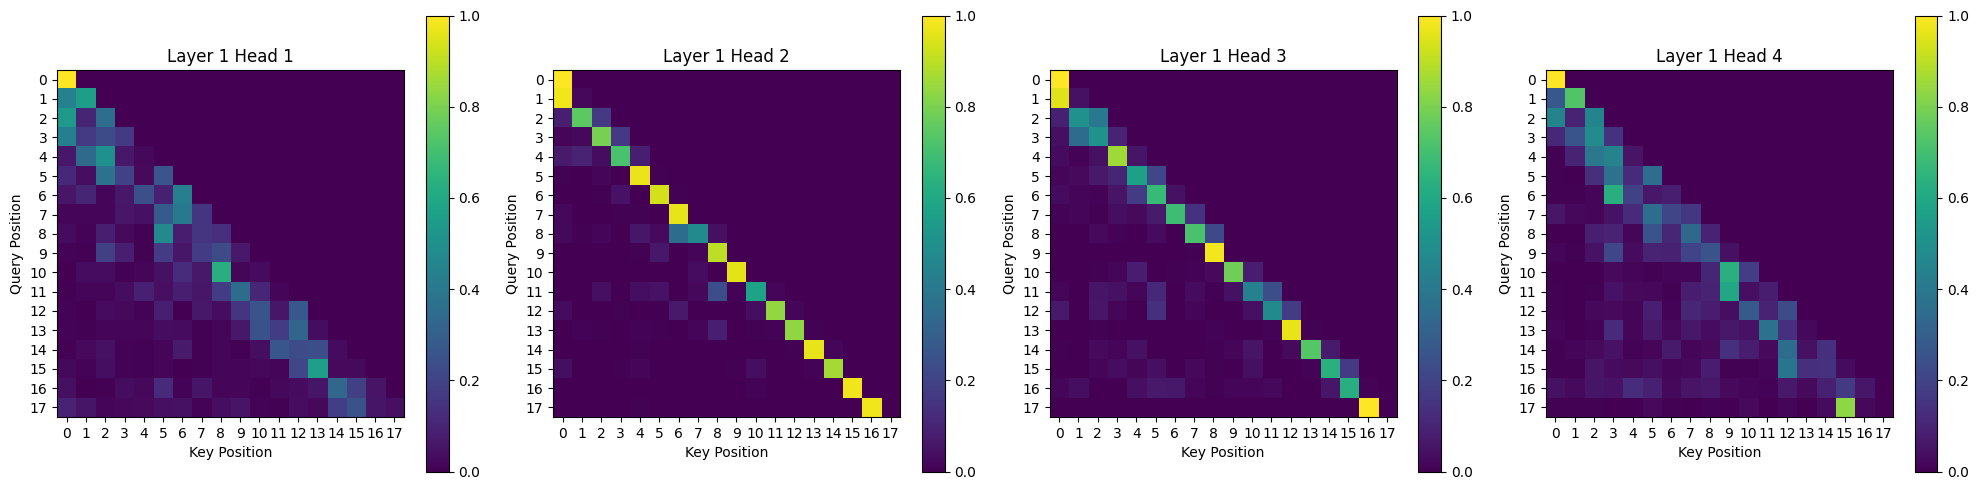

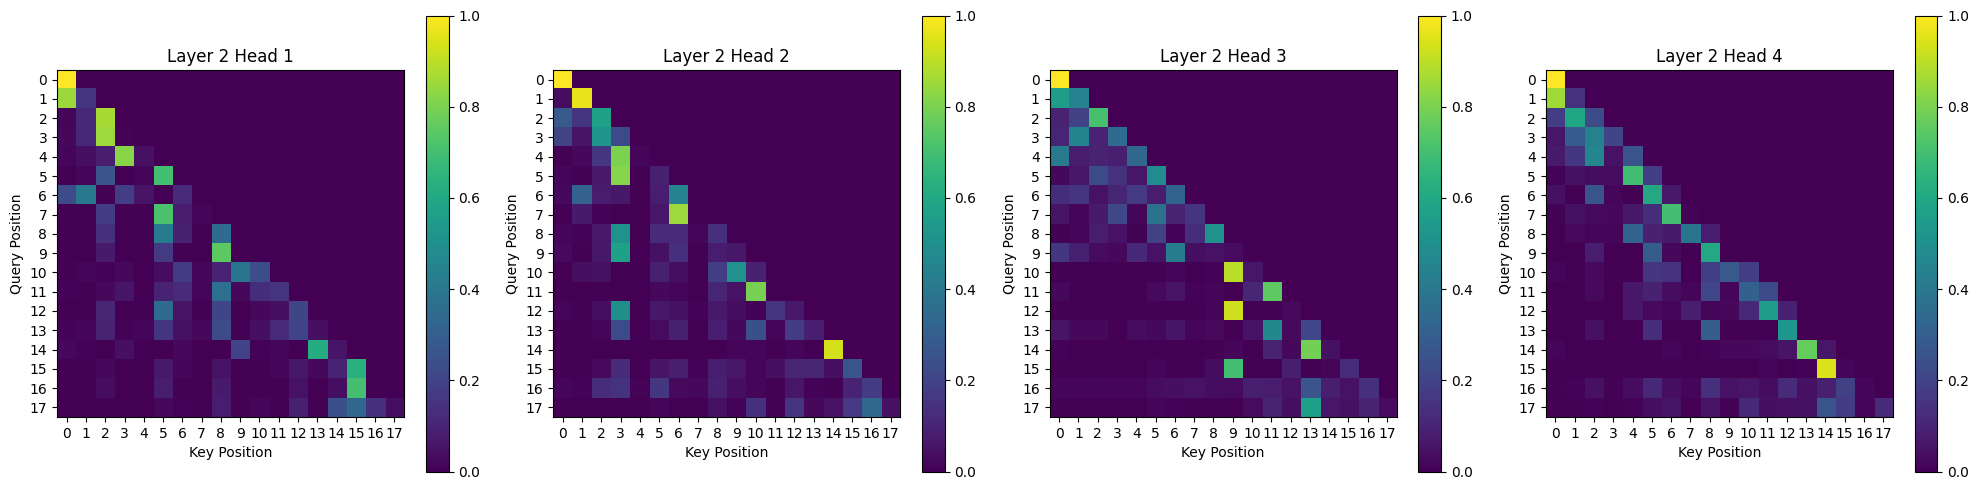

In [41]:
prompt = "To be or not to be"
visualize_attention(model, prompt)

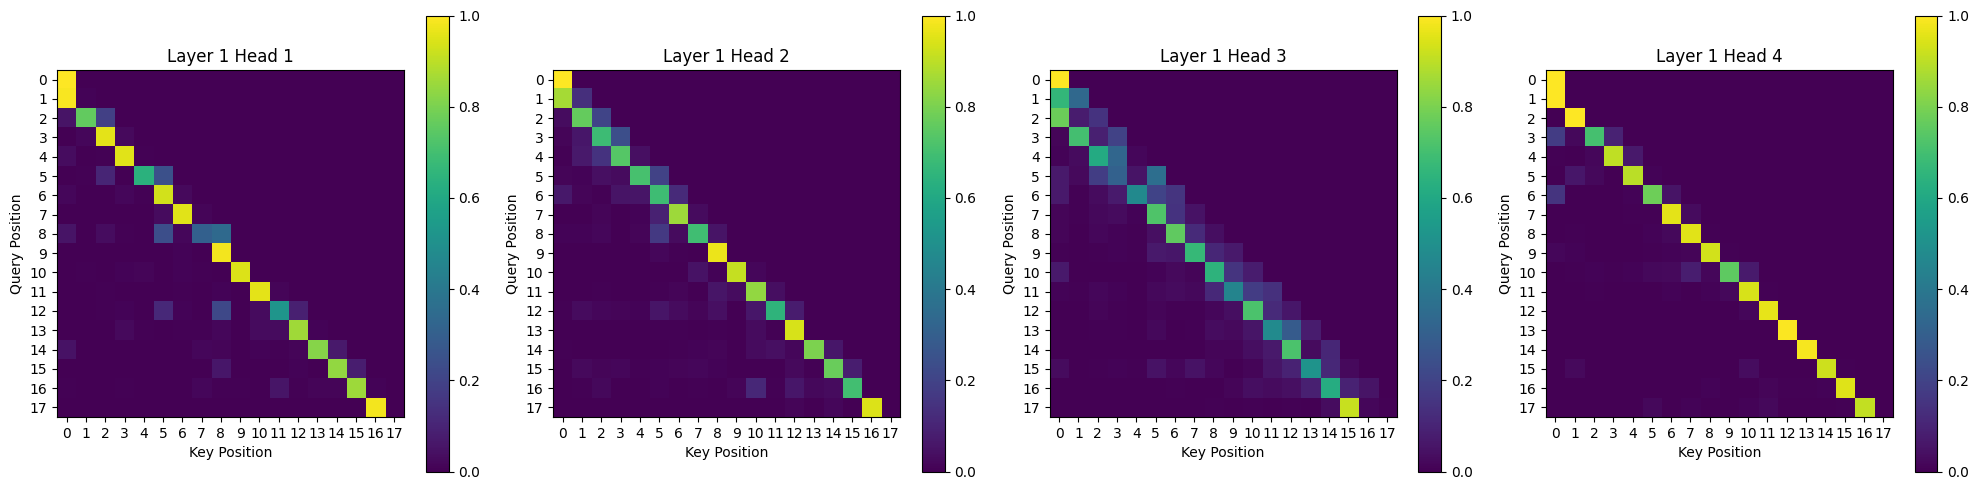

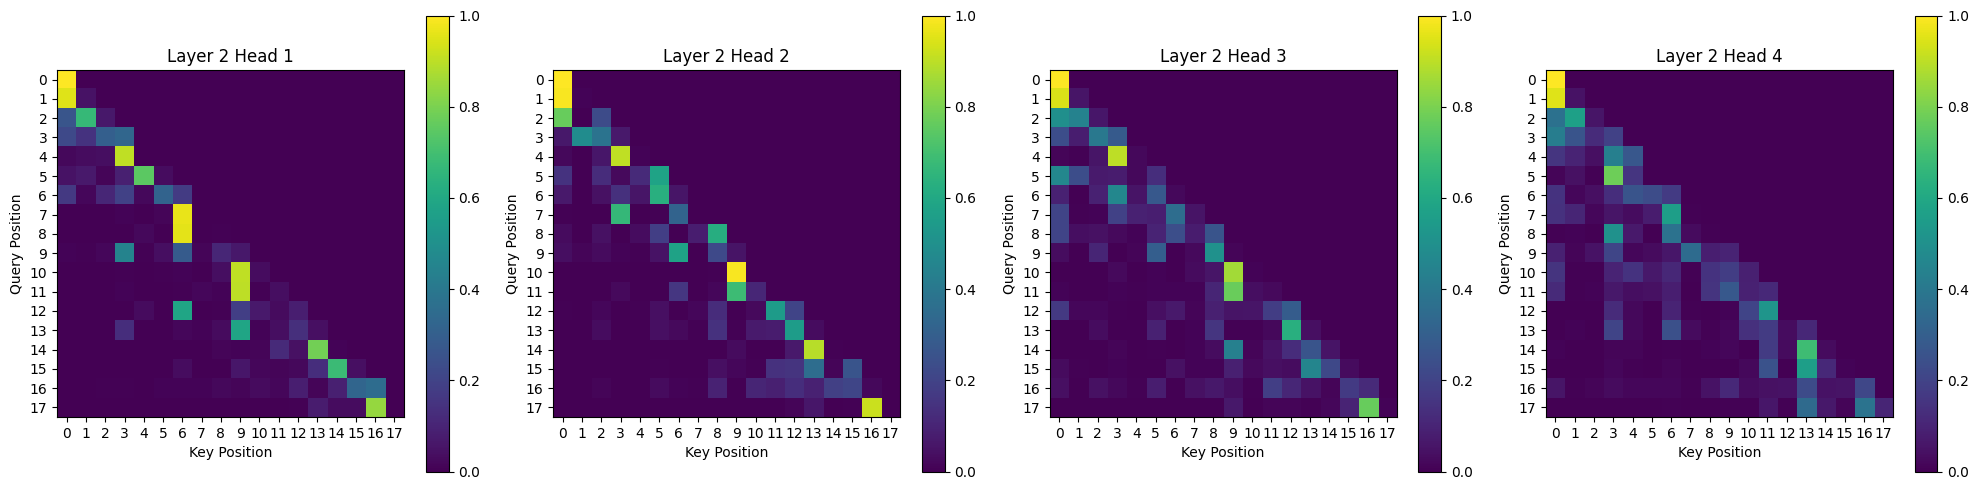

In [42]:
visualize_attention(model_moe, prompt)

## Conclusiones

- Los resultados del training de ambos modelos son parecidos, con el MoE obteniendo un loss más bajo. Es necesario verificar si esto cambia con más epochs.
- El training del MoE es 3x más lento, probablemente por el routing y los forward passes.

### Resultados de generación de secuencias

- Greedy: determinístico pero generalmente se repite la palabra `the` que es la que más probabilidad de aparecer tiene
- Alta temperatura: demasiado incoherente, no tiene ningún tipo de sentido las secuencias que genera
- Top-k/Top-p: mejor balance de diversidad y coherencia en las secuancias. Si bien todavía no convergen a un modelo usable, es necesario seguir evolucionando la solución por este camino.

### Posibles mejoras

- Modelo de arquitectura pequeña. Con hardware más capaz es posible mejorar la arquitectura.
- El tokenizer es ineficiante y quizá se pueden obtener mejores resultados con un tokenizer por palabras
- Más epochs en el training de los modelos
- Para el MoE se pueden explorar entrenamientos con más experts y diferentes estrategias de ruteo.

### Aprendizajes

- Las estrategias de sampleo tienen mucho impacto en el resultado obtenido, es posible tener un buen modelo que no funciones debido a una estrategia de sampleo mal aplicada
- Los MoE tienen un tradeoff entre más capacidad pero training más lento. Para ver los beneficios claramente es necesario tener modelos más grandes con un dataset más grande posiblemente más epochs de entrenamiento para obtener un loss que se estabilice cerca de un valor, lo cual no hemos visto con las epochs que pude correr en mi máquina.


# Congratulations! 🎉

After completing the tasks you've successfully pretrained for first GPT, remember to add your conclusions and findings! And you can now brag to your friend on how LLMs and GPTs work!

